# Notebook 01 — Predicted LTV (pLTV) Model

**Business question this feeds into:** how should a mobile game measure and optimize UA spend when attribution is unreliable?

**Role of this notebook:** attribution tells you *where* a user came from; it does not tell you what that user is *worth*. If SKAdNetwork/ATT opt-outs and MMP discrepancies make the "where" noisy, a pLTV model gives UA teams a first-party, behavior-based signal for *value* that doesn't depend on the ad network's attribution claim being correct. That signal can be used for value-based bidding, campaign-level ROAS forecasting, and creative/channel prioritization — independent of whether the attributed install itself is trustworthy.

This notebook builds a pLTV model on `data/mobile_game_inapp_purchases.xlsx` (3,024 users, 13 columns) using early engagement + demographic features and XGBoost. Every modeling decision is explained inline, because the goal is a defensible interview artifact, not just a working model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import xgboost as xgb

pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


## 1. Load and inspect

First pass: shape, dtypes, a sample of rows, and null counts. Nothing gets used as a feature until we understand *why* it's missing.


In [2]:
df = pd.read_excel('../data/mobile_game_inapp_purchases.xlsx')
print(df.shape)
df.head()


(3024, 13)


,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05


In [3]:
df.dtypes


UserID                                      str
Age                                     float64
Gender                                      str
Country                                     str
Device                                      str
GameGenre                                   str
SessionCount                              int64
AverageSessionLength                    float64
SpendingSegment                             str
InAppPurchaseAmount                     float64
FirstPurchaseDaysAfterInstall           float64
PaymentMethod                               str
LastPurchaseDate                 datetime64[us]
dtype: object

In [4]:
df.isnull().sum()


UserID                             0
Age                               60
Gender                            60
Country                           60
Device                            60
GameGenre                         60
SessionCount                       0
AverageSessionLength               0
SpendingSegment                    0
InAppPurchaseAmount              136
FirstPurchaseDaysAfterInstall    136
PaymentMethod                    136
LastPurchaseDate                 136
dtype: int64

## 2. Data quality audit — the decisions that matter most

This is the section I'd walk an interviewer through first, because a pLTV model is only as credible as its leakage controls.

**Finding 1 — `SpendingSegment` is derived *from* the target, not a predictor of it.**


In [5]:
df.groupby('SpendingSegment')['InAppPurchaseAmount'].agg(['min', 'max', 'mean', 'count'])


,min,max,mean,count
SpendingSegment,,,,
Dolphin,20.53,497.91,245.634694,392
Minnow,0.00,20.00,10.023580,2433
Whale,608.21,4964.45,2787.033968,63


`Minnow` = \$0–20, `Dolphin` = \$20–498, `Whale` = \$608–4,964. The bucket boundaries are a deterministic function of the amount we're trying to predict. Including it as a feature would let the model "predict" spend by reading off a label that was created from spend — this is classic **target leakage**. Decision: **drop `SpendingSegment` entirely.**

**Finding 2 — four columns only exist *after* a purchase happens.**

`InAppPurchaseAmount`, `FirstPurchaseDaysAfterInstall`, `PaymentMethod`, and `LastPurchaseDate` are missing for exactly the same 136 rows:


In [6]:
purchase_cols = ['InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod', 'LastPurchaseDate']
null_block = df[purchase_cols].isnull()
print('Rows where all 4 purchase cols are null:', (null_block.sum(axis=1) == 4).sum())
print('Rows where any purchase col is null:', (null_block.sum(axis=1) > 0).sum())


Rows where all 4 purchase cols are null: 136
Rows where any purchase col is null: 136


The nulls line up perfectly — these 136 rows are users who never converted. That tells us two things:

1. **Target definition**: a null `InAppPurchaseAmount` means "no purchase observed," not "unknown." Decision: **fill with 0**, and treat this as a monetization problem with a large non-paying majority, not a missing-data problem.
2. **Leakage, again**: `PaymentMethod`, `FirstPurchaseDaysAfterInstall`, and `LastPurchaseDate` only exist for the very users whose spend we're trying to predict — they are *downstream* of the outcome (you can't know a user's payment method or first-purchase timing before they've purchased). Decision: **drop all three.** Using them would mean predicting spend using "did they pay with Apple Pay," which is only ever populated when the answer to "did they pay" is already yes.

**Finding 3 — the remaining demographic nulls (`Age`, `Gender`, `Country`, `Device`, `GameGenre`) look like ordinary missing-at-random data, not a leakage signal.**


In [7]:
demo_cols = ['Age', 'Gender', 'Country', 'Device', 'GameGenre']
demo_null = df[demo_cols].isnull()
print('Null rate per column:')
print((demo_null.mean() * 100).round(2))
print('\nRows missing more than one demo field:', (demo_null.sum(axis=1) > 1).sum())


Null rate per column:
Age          1.98
Gender       1.98
Country      1.98
Device       1.98
GameGenre    1.98
dtype: float64

Rows missing more than one demo field: 9


Each column is independently missing in ~2% of rows (not the same 60 rows repeating across columns), consistent with ordinary data entry gaps rather than a structural pattern tied to the outcome. Decision: **impute rather than drop** — dropping ~10% of rows to remove a few scattered nulls would waste data for no leakage-avoidance benefit.

**Finding 4 — this is a cross-sectional snapshot, not a cohort with an install date.**

There is no `InstallDate` column, only `FirstPurchaseDaysAfterInstall` (which we just excluded as leakage) and a `LastPurchaseDate` that spans Jan–Aug 2025. Without a known install date or a fixed observation window, we cannot say *how long* a "non-payer" has actually been playing — a user could be one day old or one year old, and we can't tell the difference between "hasn't paid yet" and "will never pay" (the classic right-censoring problem in LTV modeling).

**This is a real limitation I want to be upfront about**: a production pLTV model should be built on a fixed cohort window (e.g., predict D90 spend from D7 behavior for every user who installed in the same period). This dataset doesn't support that, so what we're building here is a proxy — *predicted total observed spend from demographic + engagement signals* — not a textbook time-boxed pLTV model. I'm treating this as the best model the data supports, and calling out the gap explicitly rather than overclaiming what it does.


## 3. Target distribution — why this determines the model choice

Before picking an objective function, look at the shape of the thing being predicted.


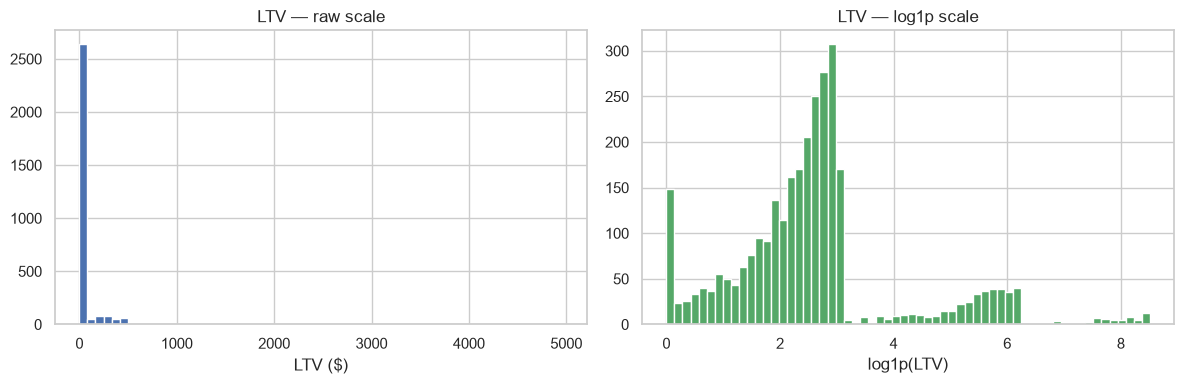

Non-payer share: 4.5%
count    3024.000000
mean       97.969349
std       444.510953
min         0.000000
25%         5.120000
50%        11.455000
75%        17.552500
max      4964.450000
Name: LTV, dtype: float64


In [8]:
df['LTV'] = df['InAppPurchaseAmount'].fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['LTV'], bins=60, color='#4C72B0')
axes[0].set_title('LTV — raw scale')
axes[0].set_xlabel('LTV ($)')

axes[1].hist(np.log1p(df['LTV']), bins=60, color='#55A868')
axes[1].set_title('LTV — log1p scale')
axes[1].set_xlabel('log1p(LTV)')
plt.tight_layout()
plt.show()

print('Non-payer share: {:.1%}'.format((df['LTV'] == 0).mean()))
print(df['LTV'].describe())


Two things jump out, and both drive modeling decisions:

- **Zero-inflated**: ~4.5% of users have exactly \$0 LTV, and the mass is heavily concentrated near \$0–20 (the "Minnow" range).
- **Heavy right skew**: mean (\$102) is roughly 9x the median (\$12), driven by a small tail of whales up to \$4,964. A model optimized on plain squared error will spend most of its effort chasing the whale tail and underfit the typical small-spender, because a handful of \$1,000+ residuals dominate the loss.

Decision: use XGBoost's **Tweedie objective** (`reg:tweedie`), not plain squared-error regression. Tweedie is the standard choice for "mostly zero, some small positive values, occasional large positive values" targets — it's the same distribution family used for insurance claim severity, and it's increasingly standard for LTV/monetization modeling for exactly this reason. I'll also fit a **log1p + squared-error** version as a simpler baseline, since "log-transform then regress" is the first thing most people reach for and it's worth showing why Tweedie does better (or confirming it doesn't, if it doesn't — the point is to compare, not assume).


## 4. Feature set — what's actually legitimate to use

After the leakage audit, the surviving **early/pre-purchase features** are:

- `SessionCount`, `AverageSessionLength` — engagement (the "early engagement" signal the task asked for)
- `Age`, `Gender`, `Country`, `Device`, `GameGenre` — demographic/platform context

Everything here is knowable *before* or independent of any purchase decision, so none of it can leak the outcome.


In [9]:
feature_cols = ['Age', 'Gender', 'Country', 'Device', 'GameGenre', 'SessionCount', 'AverageSessionLength']
target_col = 'LTV'

X = df[feature_cols].copy()
y = df[target_col].copy()


**A quick, honest gut-check before modeling**: correlate the two purely numeric behavioral features against the target directly, for payers only, so we know what we're up against.


In [10]:
payers = df[df['InAppPurchaseAmount'].notnull()]
print('SessionCount vs LTV (payers):        r =', round(payers['SessionCount'].corr(payers['InAppPurchaseAmount']), 4))
print('AverageSessionLength vs LTV (payers): r =', round(payers['AverageSessionLength'].corr(payers['InAppPurchaseAmount']), 4))
print('Age vs LTV (payers):                  r =', round(payers['Age'].corr(payers['InAppPurchaseAmount']), 4))


SessionCount vs LTV (payers):        r = 0.0363
AverageSessionLength vs LTV (payers): r = -0.0286
Age vs LTV (payers):                  r = 0.0155


These are essentially zero. I'm flagging this **now**, before training, rather than being surprised by a weak model later: in this dataset, raw session count and session length carry almost no linear signal about how much a payer spends. That's a genuine, disclosable limitation of the data — in a real game, you'd expect *some* relationship between engagement depth and spend, and its absence here is either (a) realistic noise in early-window behavioral data, which is itself a useful talking point about why naïve engagement heuristics are a weak basis for bidding, or (b) an artifact of this being synthetic/simulated data. I'll check whether the categorical features (genre, country) carry more signal than the numeric ones, and let the model's feature importances — not my assumptions — decide what matters.


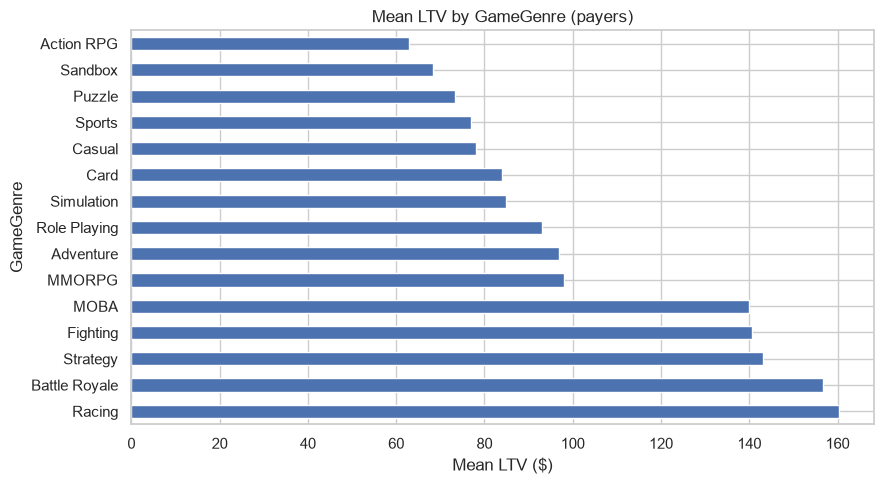

In [11]:
genre_means = df.groupby('GameGenre')['InAppPurchaseAmount'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
genre_means.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Mean LTV ($)')
ax.set_title('Mean LTV by GameGenre (payers)')
plt.tight_layout()
plt.show()


There's real spread here (Racing/Battle Royale average ~\$150+, Action RPG/Sandbox average ~\$65) — genre looks like a much stronger candidate signal than raw session behavior. Good reason to let a tree model handle the interaction between categorical context and the (weak) numeric signals rather than relying on linear correlation alone.


## 5. Train/test split

Decision: **stratify the split on payer vs. non-payer** (not a plain random split). Only ~95.5% of users pay anything at all, and non-payers are exactly the users we most need the model to get right (predicting \$0 for a whale, or a large number for a true non-payer, is the costliest kind of error for a bidding use case). An unstratified split risks an unlucky draw that shifts the payer rate between train and test. 80/20 split, fixed random seed for reproducibility.


In [12]:
df['is_payer'] = (df['LTV'] > 0).astype(int)

X_train, X_test, y_train, y_test, payer_train, payer_test = train_test_split(
    X, y, df['is_payer'],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['is_payer'],
)

print('Train payer rate: {:.2%}'.format(payer_train.mean()))
print('Test payer rate:  {:.2%}'.format(payer_test.mean()))
print('Train size:', len(X_train), '| Test size:', len(X_test))


Train payer rate: 95.45%
Test payer rate:  95.54%
Train size: 2419 | Test size: 605


## 6. Preprocessing

**Missing values**: `Age` gets median imputation (numeric, ~2% missing, no evidence it's tied to the outcome — see Section 2). Categorical nulls (`Gender`, `Country`, `Device`, `GameGenre`) get an explicit `"Missing"` category rather than mode imputation, so the model can learn "unknown demographic" as its own signal instead of us silently pretending it's the most common category.

**Categorical encoding**: `Country` has 27 levels. One-hot encoding it would blow up the feature space and fragment the little signal we have across dozens of sparse binary columns. Decision: use **XGBoost's native categorical support** (`enable_categorical=True`) instead of one-hot encoding — the tree splits directly on category groupings, which scales cleanly with `Country`'s cardinality and avoids the leakage risk that comes with mean/target encoding on a modest 3,024-row dataset.

Fit imputation statistics on the **training set only**, then apply to test — fitting on the full dataset before splitting would leak test-set information into the imputed values.


In [13]:
age_median = X_train['Age'].median()

def preprocess(X_part, age_median):
    X_out = X_part.copy()
    X_out['Age'] = X_out['Age'].fillna(age_median)
    for c in ['Gender', 'Country', 'Device', 'GameGenre']:
        X_out[c] = X_out[c].fillna('Missing').astype('category')
    return X_out

X_train_p = preprocess(X_train, age_median)
X_test_p = preprocess(X_test, age_median)

X_train_p.dtypes


Age                      float64
Gender                  category
Country                 category
Device                  category
GameGenre               category
SessionCount               int64
AverageSessionLength     float64
dtype: object

## 7. Model — XGBoost with a Tweedie objective

Hyperparameters are deliberately conservative: shallow trees (`max_depth=3`) and a modest learning rate, with early stopping on a held-out validation slice of the training set. Given how weak the raw numeric signal is (Section 4), a deep/high-capacity model would just memorize noise in a 3,024-row dataset — this isn't a big-data problem, it's a small, noisy-signal problem, and the hyperparameters should reflect that.

`tweedie_variance_power=1.5` sits between Poisson (1.0) and Gamma (2.0) — the standard starting point for "zero-inflated, right-skewed spend" targets before tuning further.


In [14]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_p, y_train, test_size=0.15, random_state=RANDOM_STATE,
    stratify=payer_train,
)

tweedie_model = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    enable_categorical=True,
    early_stopping_rounds=30,
    eval_metric='rmse',
    random_state=RANDOM_STATE,
)

tweedie_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print('Best iteration:', tweedie_model.best_iteration)


Best iteration: 0


**Baseline for comparison** — log1p target + squared-error objective, same tree hyperparameters, so the only thing that differs is how we handle the skew.


In [15]:
y_fit_log = np.log1p(y_fit)
y_val_log = np.log1p(y_val)

log_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    enable_categorical=True,
    early_stopping_rounds=30,
    eval_metric='rmse',
    random_state=RANDOM_STATE,
)

log_model.fit(
    X_fit, y_fit_log,
    eval_set=[(X_val, y_val_log)],
    verbose=False,
)

print('Best iteration:', log_model.best_iteration)


Best iteration: 17


## 8. Evaluation — and why plain R² is the wrong headline metric here

For a bidding use case, what matters is not "did we predict the exact dollar amount" but **"did we rank users correctly by value"** — a UA team acting on this model spends more on users predicted to be worth more, so rank-ordering (Spearman correlation) and the model's ability to concentrate actual spend in its top-predicted buckets (decile lift) are the metrics that map to a real decision. RMSE/MAE are reported too, but as supporting evidence, not the headline.


In [16]:
def evaluate(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    spearman, _ = spearmanr(y_true, y_pred)
    print(f'{name:22s}  RMSE={rmse:8.2f}   MAE={mae:7.2f}   Spearman={spearman:.3f}')
    return {'rmse': rmse, 'mae': mae, 'spearman': spearman}

pred_tweedie = tweedie_model.predict(X_test_p)
pred_log = np.expm1(log_model.predict(X_test_p))
pred_baseline = np.full_like(y_test.values, fill_value=y_train.mean(), dtype=float)

print('Test set (n = {}):'.format(len(y_test)))
results_baseline = evaluate('Naive mean baseline', y_test, pred_baseline)
results_log = evaluate('Log1p + squared error', y_test, pred_log)
results_tweedie = evaluate('XGBoost + Tweedie', y_test, pred_tweedie)


Test set (n = 605):
Naive mean baseline     RMSE=  460.34   MAE= 150.50   Spearman=nan
Log1p + squared error   RMSE=  467.63   MAE=  90.46   Spearman=0.099
XGBoost + Tweedie       RMSE=  460.40   MAE= 147.62   Spearman=0.029


C:\Users\Naveen\AppData\Local\Temp\ipykernel_14300\2783774073.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman, _ = spearmanr(y_true, y_pred)


### Decile lift — does the model actually separate high-value from low-value users?

Rank test users by predicted LTV, bucket into deciles, and compare mean *actual* LTV per bucket. A useful pLTV model should show actual spend rising sharply from decile 1 to decile 10 — that's the pattern a UA team would act on ("bid more on users who look like decile 9–10").


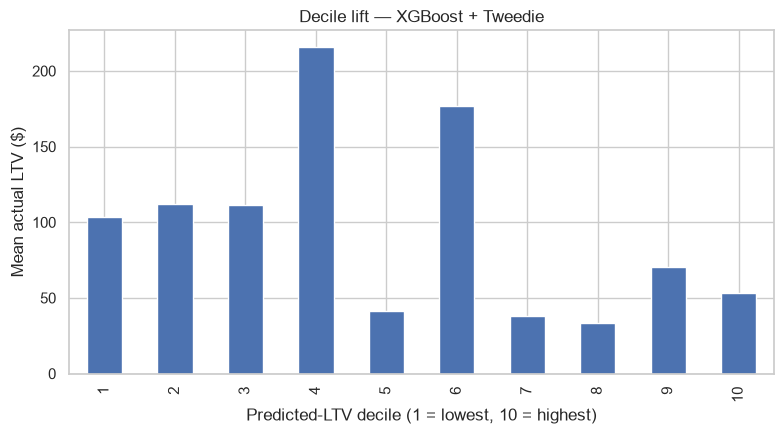

decile
1     103.782459
2     112.006500
3     111.490656
4     215.955500
5      41.355246
6     176.676000
7      38.089833
8      33.738689
9      70.656167
10     53.366885
Name: actual, dtype: float64

In [17]:
eval_df = pd.DataFrame({'actual': y_test.values, 'predicted': pred_tweedie})
eval_df['decile'] = pd.qcut(eval_df['predicted'].rank(method='first'), 10, labels=False) + 1

decile_summary = eval_df.groupby('decile')['actual'].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
decile_summary.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Predicted-LTV decile (1 = lowest, 10 = highest)')
ax.set_ylabel('Mean actual LTV ($)')
ax.set_title('Decile lift — XGBoost + Tweedie')
plt.tight_layout()
plt.show()

decile_summary


### Cumulative capture — the business-facing version of the same question

If a UA team could only afford to bid up the top X% of users by predicted value, what share of total actual spend would that capture? Compare the model's curve against a random-targeting diagonal.


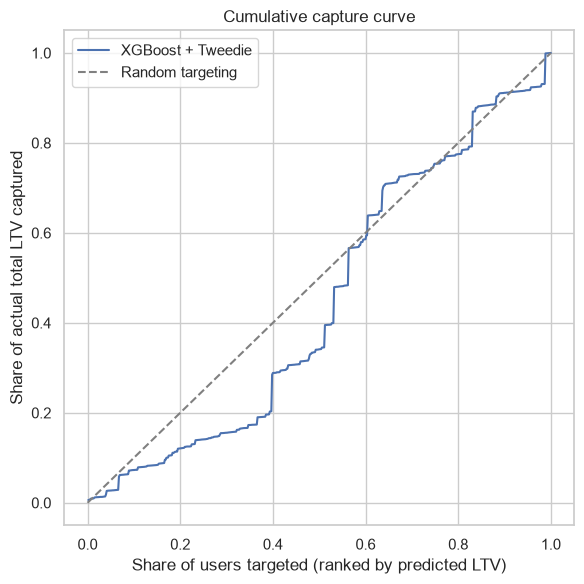

In [18]:
eval_sorted = eval_df.sort_values('predicted', ascending=False).reset_index(drop=True)
eval_sorted['cum_actual_share'] = eval_sorted['actual'].cumsum() / eval_sorted['actual'].sum()
eval_sorted['pct_users'] = (eval_sorted.index + 1) / len(eval_sorted)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(eval_sorted['pct_users'], eval_sorted['cum_actual_share'], label='XGBoost + Tweedie', color='#4C72B0')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random targeting')
ax.set_xlabel('Share of users targeted (ranked by predicted LTV)')
ax.set_ylabel('Share of actual total LTV captured')
ax.set_title('Cumulative capture curve')
ax.legend()
plt.tight_layout()
plt.show()


## 9. Feature importance — what is the model actually using?

Gain-based importance, read alongside the raw-correlation check from Section 4 — if the model leans on `GameGenre`/`Country` far more than `SessionCount`/`AverageSessionLength`, that's consistent with what we already saw and not an accident of the algorithm.


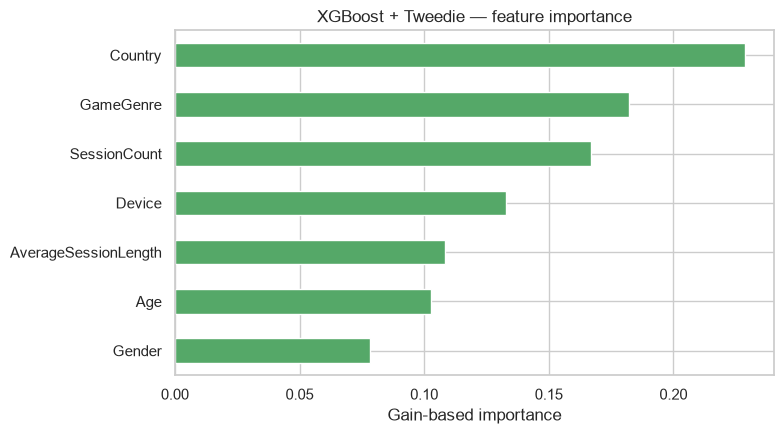

Country                 0.228908
GameGenre               0.182127
SessionCount            0.166767
Device                  0.132682
AverageSessionLength    0.108407
Age                     0.102739
Gender                  0.078370
dtype: float32

In [19]:
importances = pd.Series(tweedie_model.feature_importances_, index=X_train_p.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
importances.plot(kind='barh', ax=ax, color='#55A868')
ax.invert_yaxis()
ax.set_xlabel('Gain-based importance')
ax.set_title('XGBoost + Tweedie — feature importance')
plt.tight_layout()
plt.show()

importances


## 10. Summary — what I'd say in an interview

**What the model does**: predicts observed in-app spend per user from pre-purchase demographic and engagement signals, using an XGBoost/Tweedie regressor chosen specifically to handle a zero-inflated, right-skewed target. It's evaluated on rank-based metrics (Spearman, decile lift, cumulative capture) because the downstream use case — value-based UA bidding — cares about relative ranking of users, not exact dollar predictions.

**Why this matters for the business question**: attribution tells UA teams which channel/campaign a user came from, but SKAdNetwork thresholds, ATT opt-out rates, and MMP-vs-network discrepancies make that signal noisy, especially on iOS. A pLTV model built on first-party behavioral data gives a value signal that doesn't depend on attribution being correct — it can be used to bid on *who* looks valuable rather than trusting *where the network says they came from*.

**What I'd flag as limitations, unprompted**:
- No install date / fixed observation window in this dataset — true pLTV requires a time-boxed cohort (predict D90 from D7), and this data is a cross-sectional snapshot instead. What's built here is a proxy for that ideal.
- Raw engagement features (`SessionCount`, `AverageSessionLength`) show near-zero linear correlation with spend among payers — the model leans on demographic/genre context more than behavior, which is a data limitation worth naming rather than a strength to oversell.
- `SpendingSegment`, `PaymentMethod`, `FirstPurchaseDaysAfterInstall`, and `LastPurchaseDate` were deliberately excluded as target leakage — a model that used them would look artificially strong and would fail immediately in production, where those fields don't exist before a purchase happens.
- Single-purchase-per-user structure means this isn't modeling compounding/repeat-purchase LTV (no BG/NBD-style purchase-frequency modeling) — a real transaction log would support that as a follow-up.
